# Programmering i Python - Halveringsmetoden

Målet i denne økta er å kunna løysa likningar numerisk vha. eigenprogrammerte funksjonar.

I forrige økt såg me på bruken av variablar og tilordningar.
Dette er ein av dei to grunnleggjande mekanismane i imperativ programmering.
Den andre grunnleggjande mekanismen som me må kunna er kontrollflyt.

## Kontrollflyt

Når ei kodeline vert køyrd i programmet, seier me at lina har *kontrollen*. 
Det er ikkje alltid at me ynskjer at kontrollen skal flyta vidare til neste kodeline.
Av og til vil me hoppa over kode avhengig av verdien på ein eller annan variable.

Lat oss definera ein variabel til testen.

In [1]:
testvar = 10

# Vilkår

Alle imperative programmeringsspråk har ein vilkårssats.
I python ser han slik ut.

In [2]:
if testvar <= 0: print( "Ikkje-positivt tal")
else: print ("Positivt tal") 

Positivt tal


Evt. kan ein ha meir enn to alternativ.

In [3]:
if testvar < 0: print( "Negativt tal")
elif testvar > 0: print ("Positivt tal") 
else: print( testvar )

Positivt tal


Me kan bruka vilkårssatsen inni ein funksjon:

In [4]:
def testfun(testvar):
    if testvar < 0: print( testvar, "Negativt tal")
    elif testvar > 0: print (testvar, "Positivt tal") 
    else: print( testvar )

In [5]:
testfun(-17)
testfun(3.4)
testfun(0)

-17 Negativt tal
3.4 Positivt tal
0


# Løkke (repetisjon)

Alle imperative språk har òg løkker.  Der finst gjerne fleire variantar.
Den mest kompakte er for-løkka, som ser slik ut.

In [6]:
for i in range(7):
    print( "Repetisjon nr. ", i)

Repetisjon nr.  0
Repetisjon nr.  1
Repetisjon nr.  2
Repetisjon nr.  3
Repetisjon nr.  4
Repetisjon nr.  5
Repetisjon nr.  6


I for-løkka er der alltid ein indeksvariabel (`i` i dette tilfellet) som vert definert som ein del av sjølve løkkesyntaksen. I `while`-løkka er det ikkje tilfellet:

In [7]:
while testvar > 0:
        print( "Repetisjon nr. ", testvar)
        testvar = testvar - 2

Repetisjon nr.  10
Repetisjon nr.  8
Repetisjon nr.  6
Repetisjon nr.  4
Repetisjon nr.  2


### Oppgåve

Merk at ``testvar`` har endra verdi.  Kva skjer om du køyrer dei blokkane over
(``if``- og ``while``-satsane) over ein gong til?



## Eit enkelt døme

Lat oss sjå på tredjegradsfunksjonen $f(x) = 3x^3 + 10x^2 - 50x - 3$

In [1]:
def f(x): return 3*x**3 + 10*x**2 - 50*x - 3

Me kan testa funksjonen ved å plott:

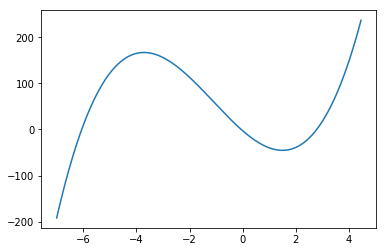

In [15]:
from matplotlib import pyplot as plt
%matplotlib inline

plt.plot()
x = [ i/20 for i in range(-140,90) ]
y = [f(i) for i in x]
plt.plot(x,y,"-")


Me ser at funksjonen byter forteikn mellom 0 og 1, og sidan han er kontinuerleg, må der vera eit nullpunkt der. Me kan bruka halveringsmetoden for å finna nullpunktet.

In [3]:
def bisect(f,lower,upper):
    while abs(lower-upper) > 0.01: 
        midpoint = (lower+upper)/2
        if f(lower)*f(midpoint) < 0: upper = midpoint
        elif f(midpoint)*f(upper) < 0: lower = midpoint
    return (lower+upper)/2
print ( bisect(f,-2,2))


-0.05859375


### Oppgåve

Finn dei to andre nullpunkta vha. halveringsmetoden.

## Forenkling av funksjonen

Legg merke til at ``bisect`` reknar ut ``f(midpoint)`` to gongar.
Her er det ikkje noko problem, men dersom det tek tid å rekna ut $f$ er det bortkasta arbeid.
Det kan difor løna seg å endra funksjonen slik:

In [4]:
def bisect2(f,lower,upper):
    while abs(lower-upper) > 0.01: 
        midpoint = (lower+upper)/2
        fm = f(midpoint)
        if f(lower)*fm < 0: upper = midpoint
        elif fm*f(upper) < 0: lower = midpoint
    return (lower+upper)/2
print(bisect2(f,-2,2))

-0.05859375


## Rekursjon

Hittil har me brukt ei while-løkke for å iterera over eit stadig mindre interval. I staden for løkka, kan ein bruka rekursjon; dvs. at funksjonen kallar seg sjølv.

In [ ]:
def bisectR(f,l,u):
    fl = f(l)
    fu = f(u)
    if fl*fu >= 0: raise Exception ("Funksjonen byter ikkje forteikn på intervallet")
    m = (l+u)/2
    fm = f(m)
    if abs(l-u) < 0.01: return m
    elif fm == 0: return m
    elif fl*fm < 0: return bisectR(f,l,m)
    elif fm*fu < 0: return bisectR(f,m,u)
print ( bisectR(f,0,1))

Legg merke til feilsjekken, som sikrar at me ikkje køyrer halveringsmetoden på eit intervall der funksjonen har same forteikn i båe endane.
Det er ein god skikk å sikra seg mot alle tenkjelege feil på denne måten, men det er krevjande å tenkja på alt.  Dei fleste døma i dette kurset slurvar med denne typen feilsjekking.

**Oppgåve:** Kva skjer om du droppar feilsjekken og køyrer t.d. ``bisectR(f,-1,0)``?


In [ ]:
def bisectRfeil(f,l,u):
    fl = f(l)
    fu = f(u)
    m = (l+u)/2
    fm = f(m)
    if abs(l-u) < 0.01: return m
    elif fm == 0: return m
    elif fl*fm < 0: return bisectR(f,l,m)
    elif fm*fu < 0: return bisectR(f,m,u)
print ( bisectRfeil(f,-1,0))

Her fekk me ``None``; dvs. funksjonen gav ikkje nokon returverdi. Korleis kan det ha seg?
Det må tyda at ingen av ``return``-satsane vart køyrde. 
Dersom du sjekkar utrekninga for hand, ser du at det gjev meining.

## Utviklinga gjennom algoritmen

Det er nyttig å sjå korleis estimatet utviklar seg steg for steg i algoritmen.
I dømet under samlar me opp alle estimata i ei liste `r`.

In [11]:
def bisect2log(function,lower,upper):
    r = []
    while abs(lower-upper) > 0.001: 
        midpoint = (lower+upper)/2
        fm = f(midpoint)
        if f(lower)*fm < 0: upper = midpoint
        elif fm*f(upper) < 0: lower = midpoint
        r += [midpoint]
    midpoint = (lower+upper)/2
    return r
xs = bisect2log(f,-2,2)
print(xs)

[0.0, -1.0, -0.5, -0.25, -0.125, -0.0625, -0.03125, -0.046875, -0.0546875, -0.05859375, -0.060546875, -0.0595703125]


Merk at det siste talet i lista er det same estimatet som me har fått tidlegare.
Skilnaden er at me no veit alle estimata på vegen.
Dette kan me plotta:

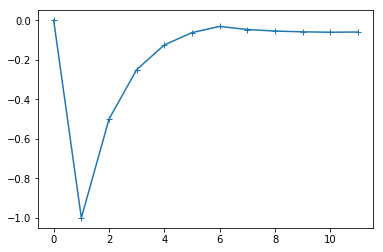

In [17]:
n = len(xs)
x = range(n)
plt.plot(x,xs,"+-")

## Oppgåve

1. Korleis kan du auka presisjonen i halveringsmetoden, og få fleire riktige desimalar i svaret?
1. Gå vidare til dokumentet om Sekantmetoden.  Det er ein raskara algoritme i dei fleste tilfelle. Dokumentet gjev hovudstega, men du må fullføra algoritmen vha. idéane som me har presentert her.

## Oppsummering

Det viktigaste i dette dømet er 
1. Vilkårssatsen
1. Løkker
1. Algoritmen for halveringsmetoden.
Me har òg vist rekursjon.  Alt som me kan gjera med rekursjon, kan me òg gjera med løkker og vise versa.
Det er mykje smak og behag som avgjer kva me vel.